# ChemWorld Shared World Challenge - Leaderboard And Project Blueprint

This notebook turns the twelve-day tutorial into a research-style classroom project and a lightweight leaderboard design. The central rule is simple: every track is a different task slice over the same ChemWorld physical-chemical world law.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

import chemworld  # noqa: E402,F401
from chemworld.tasks import list_task_cards  # noqa: E402

tu = importlib.import_module("tutorial_utils")
pd.set_option("display.precision", 4)
print("project root:", ROOT)


project root: D:\Projects\ChemWorld


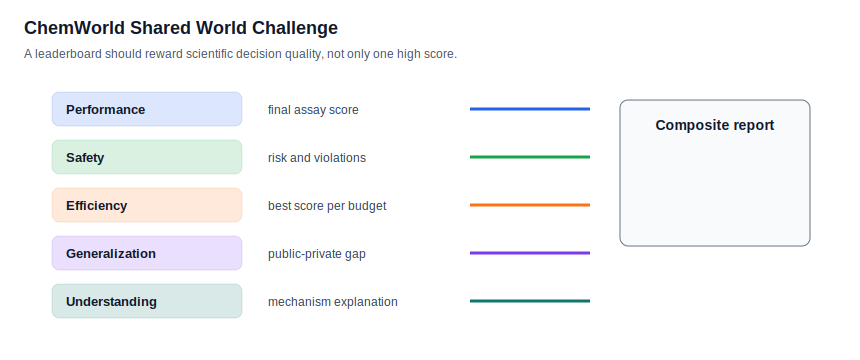

In [2]:
tu.display_project_canvas(
    title="ChemWorld Shared World Challenge",
    problem=(
        "Who can learn useful local world models and make safe closed-loop "
        "decisions under a finite experiment budget?"
    ),
    strategy=(
        "Compare humans, GPT-assisted planners, BO, safe BO, and hybrid systems "
        "on task slices of one shared world law."
    ),
    artifact=(
        "Submission bundle with trajectories, manifest, results, explanations, "
        "and replay verification."
    ),
    risks=(
        "A single public score can encourage overfitting, unsafe exploration, "
        "and shallow explanations."
    ),
)
display(tu.leaderboard_blueprint_svg())


## 1. Task Board

A project should not invent a new simulator for every group. Instead, choose one or two task cards from the shared registry.

In [3]:
cards = list_task_cards()
task_board = pd.DataFrame(
    [
        {
            "task_id": card["task_id"],
            "difficulty": card["difficulty"],
            "budget": card["budget"],
            "operations": ", ".join(card["allowed_operations"][:5])
            + ("..." if len(card["allowed_operations"]) > 5 else ""),
            "metrics": ", ".join(
                card["reward_leaderboard_metric"]["success_metrics"]
            ),
            "recommended_use": ", ".join(card["recommended_use"]),
        }
        for card in cards
    ]
)
task_board


,task_id,difficulty,budget,operations,metrics,recommended_use
0,low-budget-characterization,hard,18,"add_reagent, add_solvent, add_catalyst, heat, ...","sample_efficiency, uncertainty, local_model_qu...","BO, RL, benchmark"
1,partition-discovery,standard,48,"add_solvent, add_reagent, add_phase, add_extra...","phase_ratio, product_in_organic, product_in_aq...",benchmark
2,public-private-generalization,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, public_private_gap, rank_confidence",benchmark
3,purity-yield-tradeoff,standard,90,"add_reagent, add_solvent, add_catalyst, heat, ...","yield, purity, recovery, cost",benchmark
4,reaction-mechanism-explanation,standard,36,"add_reagent, add_solvent, add_catalyst, heat, ...","score, mechanism_explanation, failure_analysis","LLM-agent, benchmark"
5,reaction-optimization-standard,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, yield, selectivity, sample_efficiency","BO, RL, benchmark"
6,reaction-safety-constrained,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, safety_risk, constraint_violations",benchmark
7,reaction-to-assay,smoke,18,"add_reagent, add_solvent, add_catalyst, heat, ...","final_assay_score, trajectory_validity","benchmark, teaching"
8,reaction-to-purification,standard,90,"add_reagent, add_solvent, add_catalyst, heat, ...","score, purity, recovery, process_mass_balance_...",benchmark
9,tool-agent-planning,standard,48,"add_reagent, add_solvent, add_catalyst, heat, ...","trajectory_validity, validator_use, score, exp...","LLM-agent, benchmark"


## 2. Leaderboard Design

Use multiple boards. The final project grade or research ranking can report a composite score, but the visible leaderboard should preserve the trade-offs.

In [4]:
leaderboard_schema = pd.DataFrame(
    [
        {
            "board": "Performance",
            "weight": 0.30,
            "metric": "private final-assay score",
            "failure mode prevented": "only optimizing public-test",
        },
        {
            "board": "Safety",
            "weight": 0.20,
            "metric": "low risk and few violations",
            "failure mode prevented": "unsafe high-yield recipes",
        },
        {
            "board": "Sample efficiency",
            "weight": 0.20,
            "metric": "area-under-best-score / budget",
            "failure mode prevented": "brute-force search",
        },
        {
            "board": "Generalization",
            "weight": 0.15,
            "metric": "small public-private gap",
            "failure mode prevented": "overfitting public worlds",
        },
        {
            "board": "Scientific understanding",
            "weight": 0.15,
            "metric": "mechanism explanation rubric",
            "failure mode prevented": "black-box score chasing",
        },
    ]
)
leaderboard_schema


,board,weight,metric,failure mode prevented
0,Performance,0.30,private final-assay score,only optimizing public-test
1,Safety,0.20,low risk and few violations,unsafe high-yield recipes
2,Sample efficiency,0.20,area-under-best-score / budget,brute-force search
3,Generalization,0.15,small public-private gap,overfitting public worlds
4,Scientific understanding,0.15,mechanism explanation rubric,black-box score chasing


## 3. Suggested Project Tracks

Each team chooses one primary track and one secondary diagnostic. This keeps projects comparable while still leaving creative room.

In [5]:
project_tracks = pd.DataFrame(
    [
        {
            "track": "Reaction optimizer",
            "primary task": "reaction-optimization-standard",
            "core question": "Can you beat scripted chemistry without becoming unsafe?",
        },
        {
            "track": "Safety-first agent",
            "primary task": "reaction-safety-constrained",
            "core question": "How much score is worth giving up for robust low risk?",
        },
        {
            "track": "Purification strategist",
            "primary task": "reaction-to-purification",
            "core question": (
                "Can downstream processing recover purity without destroying yield?"
            ),
        },
        {
            "track": "Partition scientist",
            "primary task": "partition-discovery",
            "core question": "Can a learner infer phase behavior from sparse measurements?",
        },
        {
            "track": "Tool-using LLM planner",
            "primary task": "tool-agent-planning",
            "core question": "Can language proposals survive validator checks and replay?",
        },
    ]
)
project_tracks


,track,primary task,core question
0,Reaction optimizer,reaction-optimization-standard,Can you beat scripted chemistry without becomi...
1,Safety-first agent,reaction-safety-constrained,How much score is worth giving up for robust l...
2,Purification strategist,reaction-to-purification,Can downstream processing recover purity witho...
3,Partition scientist,partition-discovery,Can a learner infer phase behavior from sparse...
4,Tool-using LLM planner,tool-agent-planning,Can language proposals survive validator check...


## 4. Submission Bundle

A leaderboard row is only accepted if the result can be replayed. Every team submits the same bundle shape.

In [6]:
submission_bundle = {
    "manifest.json": [
        "agent_name",
        "agent_family",
        "task_id",
        "seeds",
        "command_used",
        "commit_hash",
    ],
    "trajectories/": ["one JSONL per task/seed/split"],
    "results/": ["evaluation JSON generated by chemworld evaluate or suite"],
    "explanations/": [
        "hypothesis, learned mechanism, failure analysis, next experiment rationale"
    ],
    "README.md": ["what was tried, what failed, what should be trusted"],
}
tu.show_json_panel("Required submission bundle", submission_bundle)


## 5. Example Visible Leaderboard

The numbers below are mock rows to show the shape of the board, not official benchmark results.

In [7]:
mock_board = pd.DataFrame(
    [
        {
            "team": "scripted-reference",
            "performance": 0.61,
            "safety": 0.82,
            "efficiency": 0.55,
            "generalization": 0.74,
            "understanding": 0.68,
        },
        {
            "team": "bo-optimizer",
            "performance": 0.67,
            "safety": 0.58,
            "efficiency": 0.73,
            "generalization": 0.62,
            "understanding": 0.52,
        },
        {
            "team": "safe-bo",
            "performance": 0.63,
            "safety": 0.88,
            "efficiency": 0.64,
            "generalization": 0.69,
            "understanding": 0.56,
        },
        {
            "team": "human-gpt-hybrid",
            "performance": 0.65,
            "safety": 0.76,
            "efficiency": 0.66,
            "generalization": 0.71,
            "understanding": 0.81,
        },
    ]
)
weights = leaderboard_schema.set_index("board")["weight"].to_dict()
mock_board["composite"] = (
    mock_board["performance"] * weights["Performance"]
    + mock_board["safety"] * weights["Safety"]
    + mock_board["efficiency"] * weights["Sample efficiency"]
    + mock_board["generalization"] * weights["Generalization"]
    + mock_board["understanding"] * weights["Scientific understanding"]
)
mock_board.sort_values("composite", ascending=False)


,team,performance,safety,efficiency,generalization,understanding,composite
3,human-gpt-hybrid,0.65,0.76,0.66,0.71,0.81,0.7070
2,safe-bo,0.63,0.88,0.64,0.69,0.56,0.6805
0,scripted-reference,0.61,0.82,0.55,0.74,0.68,0.6700
1,bo-optimizer,0.67,0.58,0.73,0.62,0.52,0.6340


In [8]:
tu.display_reflection_box(
    [
        (
            "Which board should be public during development, and which should "
            "remain private until final evaluation?"
        ),
        (
            "What evidence would convince you that an agent learned chemistry "
            "rather than exploited a scoring loophole?"
        ),
        (
            "What should be mandatory in every project README before a "
            "leaderboard row is accepted?"
        ),
    ]
)
